In [1]:
# A1 - Project Root Setup

from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)

print(
    "PROJECT_ROOT:",
    PROJECT_ROOT
)

assert (
    PROJECT_ROOT / "configs"
).exists()

assert (
    PROJECT_ROOT / "src"
).exists()

print(
    "Project structure verified."
)

PROJECT_ROOT: d:\IITG\Projects\audio_factor_disentanglement_v2
Project structure verified.


In [2]:
# A2 - Imports

import os
import gc
import copy
import json
import yaml
import random
import shutil
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.optim as optim

import matplotlib.pyplot as plt

import wandb

from src.utils.config_loader import (
    load_yaml
)

from src.dataset.feature_loader import (
    build_dataloader
)

from src.models.factorized.factorized_vae import (
    FactorizedVAE
)

from src.losses.total_loss import (
    TotalLoss
)

from src.trainers.trainer import (
    Trainer
)

from src.trainers.beta_scheduler import (
    BetaScheduler
)

from src.trainers.factorvae_scheduler import (
    FactorVAEScheduler
)

from src.trainers.checkpoint_manager import (
    CheckpointManager
)

from src.trainers.memory_monitor import (
    MemoryMonitor
)

warnings.filterwarnings(
    "ignore"
)

print(
    "Imports Ready"
)

Imports Ready


In [3]:
# A3 - Reproducibility

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(
    f"Seed = {SEED}"
)

Seed = 42


In [4]:
# A4 - Load Configurations

model_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "model_config.yaml"
)

train_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "train_config.yaml"
)

data_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "data_config.yaml"
)

feature_cfg = load_yaml(

    PROJECT_ROOT
    /
    "configs"
    /
    "feature_config.yaml"
)

print()

print(
    "Configs Loaded"
)

print()

print(
    "Training Epochs:",
    train_cfg["training"]["epochs"]
)

print(
    "Batch Size:",
    train_cfg["training"]["batch_size"]
)

print(
    "Learning Rate:",
    train_cfg["optimizer"]["lr"]
)


Configs Loaded

Training Epochs: 300
Batch Size: 2
Learning Rate: 0.0005


In [5]:
# A5 - Device Setup

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"
)

print()

print(
    "Device:",
    device
)

if torch.cuda.is_available():

    print()

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print()

    print(
        "GPU Count:",
        torch.cuda.device_count()
    )


Device: cpu


In [6]:
# A6 - Build Runtime Config

merged_cfg = copy.deepcopy(
    model_cfg
)

merged_cfg[
    "staged_activation"
] = train_cfg[
    "staged_activation"
]

merged_cfg[
    "training"
] = train_cfg[
    "training"
]

merged_cfg[
    "gradient"
] = train_cfg[
    "gradient"
]

merged_cfg[
    "mixed_precision"
] = train_cfg[
    "mixed_precision"
]

merged_cfg[
    "early_stopping"
] = train_cfg[
    "early_stopping"
]

print()

print(
    "Merged Config Ready"
)

print()

print(
    sorted(
        merged_cfg.keys()
    )
)


Merged Config Ready

['betas', 'early_stopping', 'factorized_model', 'gradient', 'losses', 'mixed_precision', 'model', 'staged_activation', 'training']


In [7]:
# A7 - Run Session

RUN_ID = datetime.now().strftime(

    "%Y%m%d_%H%M%S"
)

# RUN_NAME = (

#     f"factorized_vae_{RUN_ID}"
# )

RUN_NAME = "factorized_vae_20260622_185710"

print()

print(
    "RUN_NAME:",
    RUN_NAME
)


RUN_NAME: factorized_vae_20260622_185710


In [8]:
# A8 - Output Directories

RUN_DIR = (

    PROJECT_ROOT
    /
    "outputs"
    /
    "runs"
    /
    RUN_NAME
)

CHECKPOINT_DIR = (
    RUN_DIR
    /
    "checkpoints"
)

PLOTS_DIR = (
    RUN_DIR
    /
    "plots"
)

METRICS_DIR = (
    RUN_DIR
    /
    "metrics"
)

LATENT_DIR = (
    RUN_DIR
    /
    "latents"
)

CONFIG_DIR = (
    RUN_DIR
    /
    "configs"
)

# for folder in [

#     RUN_DIR,

#     CHECKPOINT_DIR,

#     PLOTS_DIR,

#     METRICS_DIR,

#     LATENT_DIR,

#     CONFIG_DIR
# ]:

#     folder.mkdir(

#         parents=True,

#         exist_ok=True
#     )

print()

print(
    "Run Folder:"
)

print(
    RUN_DIR
)


Run Folder:
d:\IITG\Projects\audio_factor_disentanglement_v2\outputs\runs\factorized_vae_20260622_185710


In [9]:
# A8.1 - Save Config Snapshot

with open(

    CONFIG_DIR
    /
    "model_config.yaml",

    "w"
) as f:

    yaml.safe_dump(
        model_cfg,
        f,
        sort_keys=False
    )

with open(

    CONFIG_DIR
    /
    "train_config.yaml",

    "w"
) as f:

    yaml.safe_dump(
        train_cfg,
        f,
        sort_keys=False
    )

with open(

    CONFIG_DIR
    /
    "feature_config.yaml",

    "w"
) as f:

    yaml.safe_dump(
        feature_cfg,
        f,
        sort_keys=False
    )

print(
    "Config Snapshot Saved"
)

Config Snapshot Saved


In [10]:
# A9 - WandB Setup

WANDB_PROJECT = (
    "audio_factor_disentanglement_v2"
)

wandb.init(

    project=
    WANDB_PROJECT,

    name=
    RUN_NAME,

    config={

        "epochs":
        train_cfg["training"]["epochs"],

        "batch_size":
        train_cfg["training"]["batch_size"],

        "learning_rate":
        train_cfg["optimizer"]["lr"],

        "weight_decay":
        train_cfg["optimizer"]["weight_decay"],

        "tc_gamma":
        model_cfg["losses"]["factorvae"]["gamma"],

        "orthogonality_weight":
        model_cfg["losses"]["orthogonality"]["weight"]
    }
)

print()

print(
    "WandB Initialized"
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Dell\_netrc.


wandb: Currently logged in as: prkr2048 (prkr2048-iit-guwahati-spe-student-chapter) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



WandB Initialized


In [11]:
# SECTION B - Dataset + Loader Audit

inventory_path = (
    PROJECT_ROOT
    / "data"
    / "metadata"
    / "feature_inventory_v2.csv"
)

inventory = pd.read_csv(
    inventory_path
)

print()
print("Inventory Shape:")
print(inventory.shape)

display(
    inventory.head()
)


Inventory Shape:
(311, 34)


,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,...,modgd_shape,logmel_shape,mr_mag_256_shape,mr_phase_256_shape,mr_mag_512_shape,mr_phase_512_shape,mr_mag_1024_shape,mr_phase_1024_shape,available_features,sample_rate
0,s1,clean,val,s1_clean_01.wav,0,0,0,10752,13056,0.672,...,"[513, 37]","[80, 37]","[129, 73]","[129, 73]","[257, 37]","[257, 37]","[513, 19]","[513, 19]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
1,s1,clean,train,s1_clean_01.wav,1,1,0,13056,17408,0.816,...,"[513, 69]","[80, 69]","[129, 137]","[129, 137]","[257, 69]","[257, 69]","[513, 35]","[513, 35]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
2,s1,clean,train,s1_clean_01.wav,2,2,1,18432,21888,1.152,...,"[513, 55]","[80, 55]","[129, 109]","[129, 109]","[257, 55]","[257, 55]","[513, 28]","[513, 28]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
3,s1,clean,train,s1_clean_01.wav,3,3,1,21888,23552,1.368,...,"[513, 27]","[80, 27]","[129, 53]","[129, 53]","[257, 27]","[257, 27]","[513, 14]","[513, 14]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000
4,s1,clean,train,s1_clean_01.wav,4,4,1,23552,25088,1.472,...,"[513, 25]","[80, 25]","[129, 49]","[129, 49]","[257, 25]","[257, 25]","[513, 13]","[513, 13]","['if', 'logmel', 'magnitude', 'modgd', 'mr_mag...",16000


In [12]:
# B2 Split Stats

print()
print("Split Distribution")

display(
    inventory["split"]
    .value_counts()
)


Split Distribution


split
train    265
val       46
Name: count, dtype: int64

In [13]:
# B3 Speaker Distribution

print()
print("Speaker Distribution")

display(
    inventory["speaker"]
    .value_counts()
)

display(
    pd.crosstab(
        inventory["speaker"],
        inventory["split"]
    )
)


Speaker Distribution


speaker
s2    170
s1    141
Name: count, dtype: int64

split,train,val
speaker,,
s1,120,21
s2,145,25


In [14]:
# B4 Condition Distribution

print()
print("Condition Distribution")

display(
    inventory["condition"]
    .value_counts()
)

display(
    pd.crosstab(
        inventory["condition"],
        inventory["split"]
    )
)


Condition Distribution


condition
noisy    182
clean    129
Name: count, dtype: int64

split,train,val
condition,,
clean,110,19
noisy,155,27


In [15]:
# B5 Fragment Duration Audit

print()
print("Fragment Duration Statistics")

display(
    inventory[
        [
            "duration",
            "true_length",
            "padding_ratio"
        ]
    ]
    .describe()
)


Fragment Duration Statistics


,duration,true_length,padding_ratio
count,311.000000,311.000000,311.000000
mean,0.206208,3299.334405,0.479272
std,0.091586,1465.371624,0.231277
min,0.080000,1280.000000,-0.333333
25%,0.136000,2176.000000,0.353535
50%,0.184000,2944.000000,0.535354
75%,0.256000,4096.000000,0.656566
max,0.528000,8448.000000,0.797980


In [16]:
# B6 Log Dataset Stats To WandB

wandb.log({

    "dataset/total_fragments":
        len(inventory),

    "dataset/train_fragments":
        int(
            (inventory["split"] == "train")
            .sum()
        ),

    "dataset/val_fragments":
        int(
            (inventory["split"] == "val")
            .sum()
        ),

    "dataset/num_speakers":
        inventory["speaker"]
        .nunique(),

    "dataset/num_conditions":
        inventory["condition"]
        .nunique()
})

In [17]:
# B7 Build Dataloaders

train_loader = build_dataloader(
    PROJECT_ROOT,
    split="train"
)

val_loader = build_dataloader(
    PROJECT_ROOT,
    split="val"
)

print()
print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches:",
    len(val_loader)
)


Train batches: 131
Val batches: 23


In [18]:
# B8 Dataset Object Audit

train_dataset = train_loader.dataset

print()
print(
    "Dataset Length:",
    len(train_dataset)
)

print(
    "Dataset Type:",
    type(train_dataset)
)


Dataset Length: 265
Dataset Type: <class 'src.dataset.feature_dataset.FeatureDataset'>


In [19]:
# B9 Single Sample Audit

sample = train_dataset[0]

print()
print(
    type(sample)
)

print()
print(
    sample.keys()
)


<class 'dict'>

dict_keys(['logmel', 'mr_mag_256', 'mr_mag_512', 'mr_mag_1024', 'magnitude', 'if', 'modgd', 'phase_sin', 'phase_cos', 'length', 'speaker', 'condition', 'split', 'fragment_id', 'source_file', 'relative_position'])


In [20]:
# B10 Feature Stats

rows = []

for name, value in sample.items():

    if not torch.is_tensor(value):
        continue

    arr = value.numpy()

    rows.append({

        "feature":
            name,

        "shape":
            tuple(arr.shape),

        "dtype":
            arr.dtype,

        "min":
            float(arr.min()),

        "max":
            float(arr.max()),

        "mean":
            float(arr.mean()),

        "std":
            float(arr.std())
    })

audit_df = pd.DataFrame(
    rows
)

display(
    audit_df
)

,feature,shape,dtype,min,max,mean,std
0,logmel,"(80, 69)",float32,0.00000,1.00000,0.403983,0.251071
1,mr_mag_256,"(129, 137)",float32,0.00000,1.00000,0.255950,0.236850
2,mr_mag_512,"(257, 69)",float32,0.00000,1.00000,0.254838,0.230516
3,mr_mag_1024,"(513, 35)",float32,0.00000,1.00000,0.227005,0.218705
4,magnitude,"(513, 69)",float32,0.00000,1.00000,0.225314,0.218511
5,if,"(513, 69)",float32,-2.00199,2.00199,0.005270,1.156813
6,modgd,"(513, 69)",float32,-1.00000,1.00000,0.032119,0.945880
7,phase_sin,"(513, 69)",float32,-1.00000,1.00000,-0.000164,0.705186
8,phase_cos,"(513, 69)",float32,-1.00000,1.00000,0.002019,0.709019


In [21]:
# B11 Expected Feature Shapes

expected_freq_bins = {

    "logmel":80,

    "mr_mag_256":129,

    "mr_mag_512":257,

    "magnitude":513,

    "if":513,

    "modgd":513,

    "phase_sin":513,

    "phase_cos":513
}

for feature, freq in expected_freq_bins.items():

    tensor = sample[feature]

    print(
        feature,
        tensor.shape
    )

    assert tensor.shape[-2] == freq

logmel torch.Size([80, 69])
mr_mag_256 torch.Size([129, 137])
mr_mag_512 torch.Size([257, 69])
magnitude torch.Size([513, 69])
if torch.Size([513, 69])
modgd torch.Size([513, 69])
phase_sin torch.Size([513, 69])
phase_cos torch.Size([513, 69])


In [22]:
for feature, tensor in sample.items():

    if not torch.is_tensor(
        tensor
    ):
        continue

    print(

        f"{feature:<15}",

        "nan=",
        torch.isnan(tensor)
        .sum()
        .item(),

        "inf=",
        torch.isinf(tensor)
        .sum()
        .item()
    )

logmel          nan= 0 inf= 0
mr_mag_256      nan= 0 inf= 0
mr_mag_512      nan= 0 inf= 0
mr_mag_1024     nan= 0 inf= 0
magnitude       nan= 0 inf= 0
if              nan= 0 inf= 0
modgd           nan= 0 inf= 0
phase_sin       nan= 0 inf= 0
phase_cos       nan= 0 inf= 0


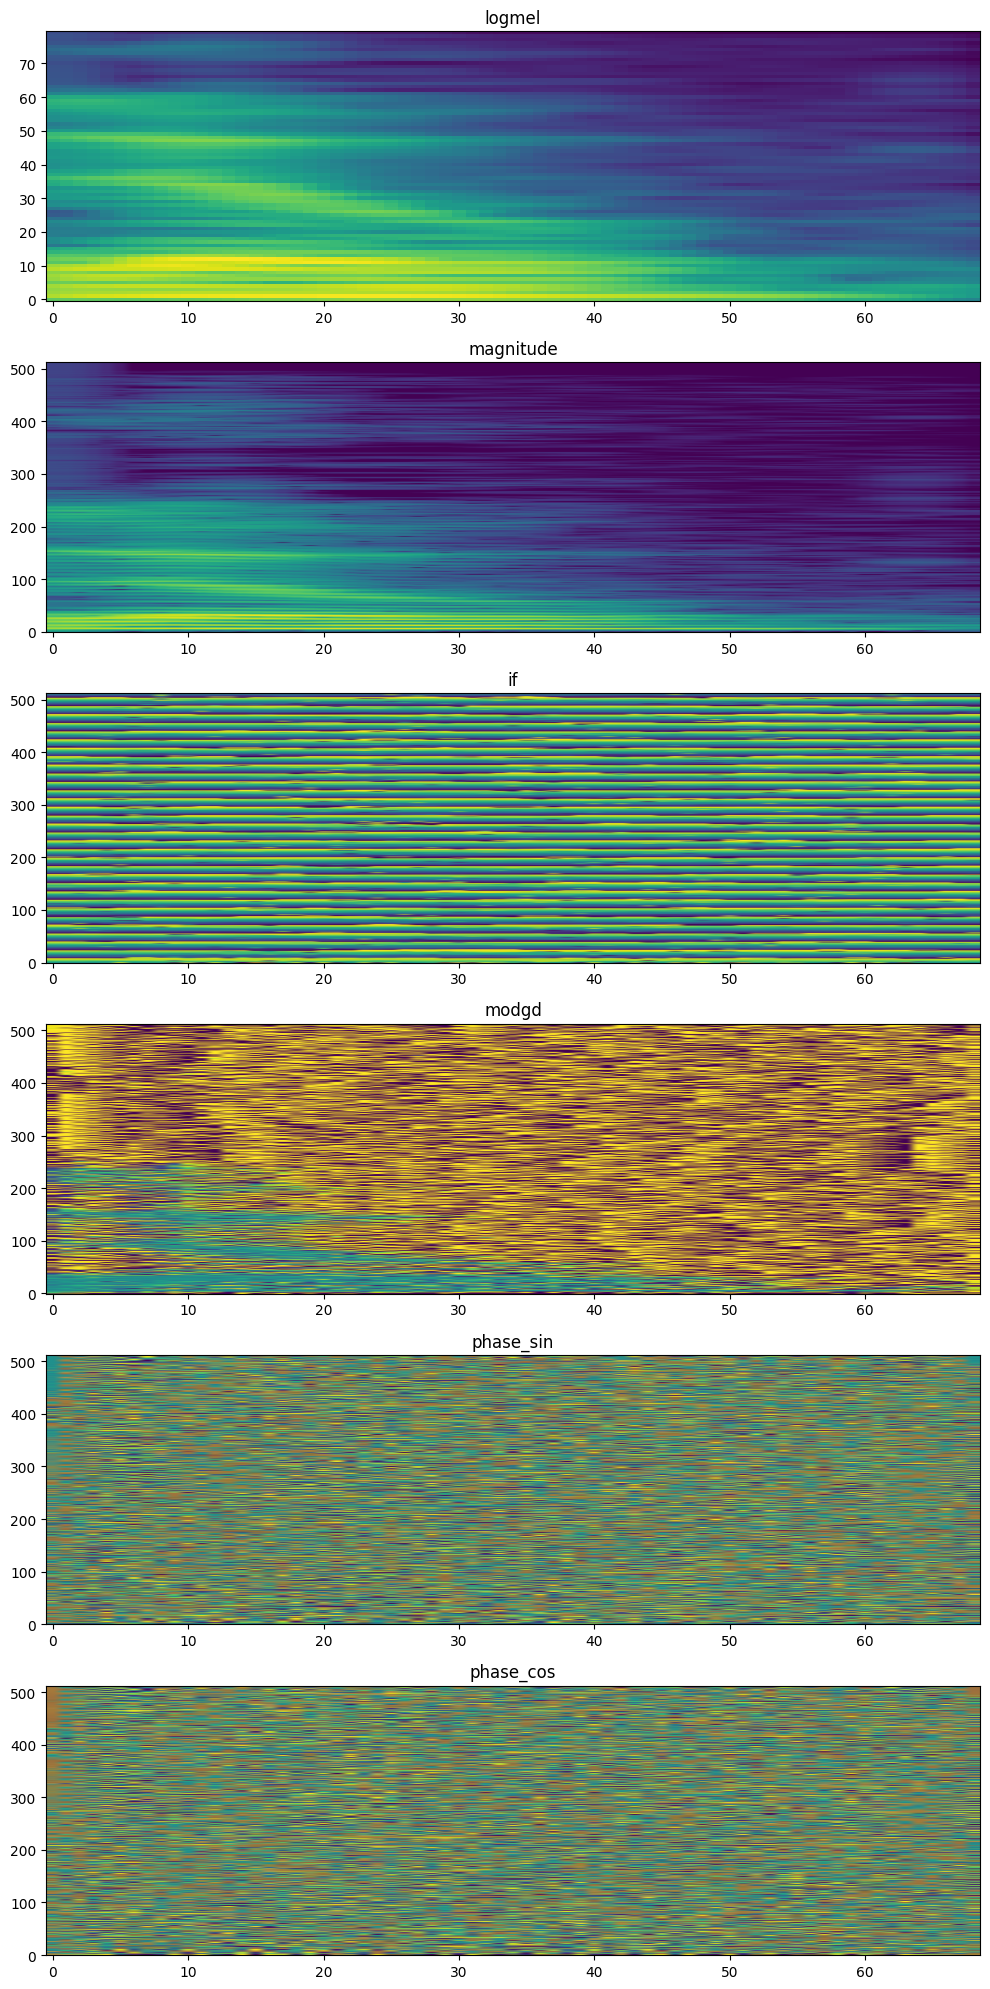

In [23]:
# B13

features_to_plot = [

    "logmel",

    "magnitude",

    "if",

    "modgd",

    "phase_sin",

    "phase_cos"
]

fig, axes = plt.subplots(

    len(features_to_plot),

    1,

    figsize=(10,20)
)

for ax, feature in zip(
    axes,
    features_to_plot
):

    image = sample[feature]

    if image.ndim == 3:
        image = image[0]

    ax.imshow(
        image,
        aspect="auto",
        origin="lower"
    )

    ax.set_title(
        feature
    )

plt.tight_layout()
plt.show()

In [24]:
# B14 Batch Audit

batch = next(
    iter(train_loader)
)

print()

for key, value in batch.items():

    if torch.is_tensor(value):

        print(
            f"{key:<15}",
            tuple(value.shape)
        )


logmel          (2, 80, 49)
mr_mag_256      (2, 129, 97)
mr_mag_512      (2, 257, 49)
mr_mag_1024     (2, 513, 25)
magnitude       (2, 513, 49)
if              (2, 513, 49)
modgd           (2, 513, 49)
phase_sin       (2, 513, 49)
phase_cos       (2, 513, 49)
lengths         (2,)


In [25]:
# B15

for key, value in batch.items():

    if not torch.is_tensor(
        value
    ):
        continue

    print(

        f"{key:<15}",

        torch.isnan(value)
        .sum()
        .item()
    )

logmel          0
mr_mag_256      0
mr_mag_512      0
mr_mag_1024     0
magnitude       0
if              0
modgd           0
phase_sin       0
phase_cos       0
lengths         0


In [26]:
# B16 Memory

total_mb = 0

for key, value in batch.items():

    if torch.is_tensor(value):

        mb = (
            value.numel()
            *
            value.element_size()
        ) / 1024**2

        total_mb += mb

        print(
            f"{key:<15}",
            f"{mb:.2f} MB"
        )

print()
print(
    f"Batch Total = {total_mb:.2f} MB"
)

logmel          0.03 MB
mr_mag_256      0.10 MB
mr_mag_512      0.10 MB
mr_mag_1024     0.10 MB
magnitude       0.19 MB
if              0.19 MB
modgd           0.19 MB
phase_sin       0.19 MB
phase_cos       0.19 MB
lengths         0.00 MB

Batch Total = 1.28 MB


In [27]:
# SECTION C - Model Construction Audit

model = FactorizedVAE(
    merged_cfg
).to(device)

print(
    type(model)
)

total_params = sum(

    p.numel()

    for p in model.parameters()
)

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

print()
print(
    f"Total Params: {total_params:,}"
)

print(
    f"Trainable Params: {trainable_params:,}"
)

<class 'src.models.factorized.factorized_vae.FactorizedVAE'>

Total Params: 73,217,893
Trainable Params: 73,217,893


In [28]:
# C2 Batch to Device

batch = next(
    iter(train_loader)
)

batch = {

    k:
    v.to(device)

    if torch.is_tensor(v)

    else v

    for k,v in batch.items()
}

print()

for k,v in batch.items():

    if torch.is_tensor(v):

        print(
            f"{k:<15}",
            tuple(v.shape)
        )


logmel          (2, 80, 69)
mr_mag_256      (2, 129, 137)
mr_mag_512      (2, 257, 69)
mr_mag_1024     (2, 513, 35)
magnitude       (2, 513, 69)
if              (2, 513, 69)
modgd           (2, 513, 69)
phase_sin       (2, 513, 69)
phase_cos       (2, 513, 69)
lengths         (2,)


In [29]:
# C3 Feature Group Audit

feature_groups = (

    model.group_manager
    .build_groups(batch)
)

print()

for group_name, group in (

    feature_groups.items()
):

    print()
    print(group_name)

    for feature_name, tensor in (

        group.items()
    ):

        print(

            f"  {feature_name:<15}",

            tuple(
                tensor.shape
            )
        )



content
  logmel          (2, 1, 80, 69)
  mr_mag_256      (2, 1, 129, 137)
  if              (2, 1, 513, 69)

speaker
  mr_mag_512      (2, 1, 257, 69)
  mr_mag_256      (2, 1, 129, 137)
  logmel          (2, 1, 80, 69)

environment
  magnitude       (2, 1, 513, 69)
  mr_mag_1024     (2, 1, 513, 35)
  if              (2, 1, 513, 69)

excitation
  modgd           (2, 1, 513, 69)

fidelity
  phase_sin       (2, 1, 513, 69)
  phase_cos       (2, 1, 513, 69)
  mr_mag_512      (2, 1, 257, 69)
  mr_mag_1024     (2, 1, 513, 35)
  magnitude       (2, 1, 513, 69)
  modgd           (2, 1, 513, 69)


In [30]:
# C4 — Encoder Audit

latents, mu, logvar = (

    model.encode(
        feature_groups
    )
)

print()

for name in latents:

    print(

        f"{name:<15}",

        "z",

        tuple(
            latents[name].shape
        ),

        "mu",

        tuple(
            mu[name].shape
        ),

        "logvar",

        tuple(
            logvar[name].shape
        )
    )


content         z (2, 64) mu (2, 64) logvar (2, 64)
speaker         z (2, 64) mu (2, 64) logvar (2, 64)
environment     z (2, 96) mu (2, 96) logvar (2, 96)
excitation      z (2, 32) mu (2, 32) logvar (2, 32)
fidelity        z (2, 128) mu (2, 128) logvar (2, 128)


In [31]:
# C5 — Latent Statistics

for name,z in latents.items():

    print()
    print(name)

    print(
        "mean:",
        z.mean().item()
    )

    print(
        "std:",
        z.std().item()
    )

    print(
        "min:",
        z.min().item()
    )

    print(
        "max:",
        z.max().item()
    )


content
mean: 0.028996439650654793
std: 1.1995335817337036
min: -2.8704938888549805
max: 3.3981683254241943

speaker
mean: -0.022209078073501587
std: 1.156175971031189
min: -2.655902624130249
max: 3.2728869915008545

environment
mean: -0.024955591186881065
std: 1.154474139213562
min: -3.3668980598449707
max: 3.84806489944458

excitation
mean: 0.2477535605430603
std: 0.8823997974395752
min: -1.4430406093597412
max: 2.0132625102996826

fidelity
mean: -0.031454235315322876
std: 1.089536428451538
min: -2.314324378967285
max: 4.344796180725098


In [32]:
# C6 — Joint Latent Audit

joint_latent = (

    model.build_joint_latent(
        latents
    )
)

print(
    "Joint Latent Shape:",
    joint_latent.shape
)

print(
    "Expected:",
    64 + 64 + 96 + 32 + 128
)

Joint Latent Shape: torch.Size([2, 384])
Expected: 384


In [33]:
# C7 — FactorVAE Scheduler Audit

factorvae_scheduler = (

    FactorVAEScheduler(

        project_root=PROJECT_ROOT,

        model=model,

        device=device
    )
)

print()

print(
    "Discriminator:"
)

print(
    factorvae_scheduler
    .discriminator
)


Discriminator:
FactorVAEDiscriminator(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=1000, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=1000, out_features=1000, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=1000, out_features=1000, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=1000, out_features=2, bias=True)
  )
)


In [34]:
# C8 — Generator TC Logits Audit

tc_outputs = (

    factorvae_scheduler
    .generator_logits(
        joint_latent
    )
)

for k,v in tc_outputs.items():

    print(
        k,
        tuple(v.shape)
    )

real (2, 2)
permuted (2, 2)


In [35]:
# C9 Full Forward Pass Audit

outputs = model(
    batch
)

print()

for k,v in outputs.items():

    if torch.is_tensor(v):

        print(
            k,
            tuple(v.shape)
        )

    elif isinstance(
        v,
        dict
    ):

        print()
        print(k)

        for kk,vv in v.items():

            if torch.is_tensor(vv):

                print(

                    f"  {kk:<15}",

                    tuple(
                        vv.shape
                    )
                )



groups

latents
  content         (2, 64)
  speaker         (2, 64)
  environment     (2, 96)
  excitation      (2, 32)
  fidelity        (2, 128)

mu
  content         (2, 64)
  speaker         (2, 64)
  environment     (2, 96)
  excitation      (2, 32)
  fidelity        (2, 128)

logvar
  content         (2, 64)
  speaker         (2, 64)
  environment     (2, 96)
  excitation      (2, 32)
  fidelity        (2, 128)

reconstructions
  logmel          (2, 80, 69)
  mr_mag_256      (2, 129, 137)
  mr_mag_512      (2, 257, 69)
  magnitude       (2, 513, 69)
  mr_mag_1024     (2, 513, 35)
  if              (2, 513, 69)
  modgd           (2, 513, 69)
  phase_sin       (2, 513, 69)
  phase_cos       (2, 513, 69)
joint_latent (2, 384)


In [36]:
# C10 — Numerical Stability Audit

def check_tensor(
    name,
    x
):

    print(

        f"{name:<20}",

        "nan=",

        torch.isnan(x)
        .sum()
        .item(),

        "inf=",

        torch.isinf(x)
        .sum()
        .item()
    )

for group in [

    "latents",

    "mu",

    "logvar"
]:

    print()
    print(group)

    for name,tensor in (

        outputs[group]
        .items()
    ):

        check_tensor(
            name,
            tensor
        )


latents
content              nan= 0 inf= 0
speaker              nan= 0 inf= 0
environment          nan= 0 inf= 0
excitation           nan= 0 inf= 0
fidelity             nan= 0 inf= 0

mu
content              nan= 0 inf= 0
speaker              nan= 0 inf= 0
environment          nan= 0 inf= 0
excitation           nan= 0 inf= 0
fidelity             nan= 0 inf= 0

logvar
content              nan= 0 inf= 0
speaker              nan= 0 inf= 0
environment          nan= 0 inf= 0
excitation           nan= 0 inf= 0
fidelity             nan= 0 inf= 0


In [37]:
# C11 — Loss Construction

loss_fn = TotalLoss(
    merged_cfg
)

print(
    type(loss_fn)
)

<class 'src.losses.total_loss.TotalLoss'>


In [38]:
# C12 — Attach TC Logits

tc_outputs = (

    factorvae_scheduler
    .generator_logits(

        outputs[
            "joint_latent"
        ]
    )
)

outputs[
    "tc_logits"
] = tc_outputs[
    "real"
]

outputs[
    "tc_logits_permuted"
] = tc_outputs[
    "permuted"
]

In [39]:
# C13 — Enable Final Training Phase

loss_fn.current_epoch = 500
loss_fn.total_epochs = 500

print(
    "All losses enabled"
)

All losses enabled


In [40]:
# C14 — Full Loss Audit

loss_dict = loss_fn(
    outputs,
    batch
)

print()

for k,v in loss_dict.items():

    if torch.is_tensor(v):

        print(
            f"{k:<30}",
            float(v.detach())
        )


[LOSS ACTIVATION STATE]
epoch=500
progress=1.0000
phase=True
kl=True
orthogonality=True
tc=True

[PHASE ACTIVATION]
epoch=500
progress=1.0000
enabled=True

[PHASE DIAGNOSTICS]
phase_derivative=0.564384
derived_if=1.103575
derived_gd=1.153961
von_mises=0.250376
phase_continuity=0.096270

[KL DIAGNOSTICS]
content KL=0.113542 BETA=0.010000
speaker KL=0.117866 BETA=0.030000
environment KL=0.100283 BETA=0.070000
excitation KL=0.091251 BETA=0.040000
fidelity KL=0.094970 BETA=0.010000

[ORTHOGONALITY]
loss=0.286387

[TC DIAGNOSTICS]
tc=-0.000193
disc=0.693581

reconstruction                 6.767359256744385
logmel_loss                    0.21914994716644287
logmel_l1                      0.19178371131420135
logmel_mse                     0.054732486605644226
mr_mag_256_loss                0.25146424770355225
mr_mag_256_l1                  0.2173404097557068
mr_mag_256_mse                 0.06824764609336853
mr_mag_512_loss                0.2597253620624542
mr_mag_512_l1                  0.2

In [41]:
# C15 — Backward Pass Audit

model.zero_grad()

loss = loss_dict[
    "total"
]

loss.backward()

In [42]:
# C16 — Gradient Audit

max_grad = 0.0

mean_grad = []

nan_count = 0

for p in model.parameters():

    if p.grad is None:
        continue

    g = p.grad.detach()

    if torch.isnan(g).any():

        nan_count += 1

    max_grad = max(

        max_grad,

        g.abs()
        .max()
        .item()
    )

    mean_grad.append(

        g.abs()
        .mean()
        .item()
    )

print(
    "Max Grad:",
    max_grad
)

print(
    "Mean Grad:",
    sum(mean_grad)
    /
    len(mean_grad)
)

print(
    "NaN Grad Tensors:",
    nan_count
)

Max Grad: 0.12211348116397858
Mean Grad: 0.0003077119456475652
NaN Grad Tensors: 0


In [43]:
# SECTION D - Training Runtime Objects

from src.losses.total_loss import (
    TotalLoss
)

from src.trainers.trainer import (
    Trainer
)

from src.trainers.beta_scheduler import (
    BetaScheduler
)

from src.trainers.factorvae_scheduler import (
    FactorVAEScheduler
)

from src.trainers.checkpoint_manager import (
    CheckpointManager
)

from src.trainers.latent_monitor import (
    LatentMonitor
)

from src.trainers.memory_monitor import (
    MemoryMonitor
)

In [44]:
# D2 Build Optimizer

optimizer_cfg = train_cfg[
    "optimizer"
]

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
    optimizer_cfg["lr"],

    weight_decay=
    optimizer_cfg["weight_decay"]
)

print(
    optimizer
)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0.0001
)


In [45]:
# D3 — Build LR Scheduler

scheduler_cfg = train_cfg[
    "scheduler"
]

scheduler = (

    torch.optim.lr_scheduler
    .CosineAnnealingLR(

        optimizer,

        T_max=
        train_cfg[
            "training"
        ][
            "epochs"
        ],

        eta_min=
        scheduler_cfg[
            "min_lr"
        ]
    )
)

print(
    scheduler
)

In [46]:
# D4 — Build Loss Function

loss_fn = TotalLoss(
    merged_cfg
)

print(
    type(loss_fn)
)

<class 'src.losses.total_loss.TotalLoss'>


In [47]:
# D5 — Sanity Check Runtime Components

beta_scheduler = (

    BetaScheduler(
        PROJECT_ROOT
    )
)

latent_monitor = (

    LatentMonitor(
        PROJECT_ROOT
    )
)

checkpoint_manager = CheckpointManager(

    project_root=PROJECT_ROOT,

    checkpoint_dir=CHECKPOINT_DIR
)

memory_monitor = (
    MemoryMonitor()
)

factorvae_scheduler = (

    FactorVAEScheduler(

        project_root=
        PROJECT_ROOT,

        model=
        model,

        device=
        device
    )
)

print(
    "Runtime Components Ready"
)

Runtime Components Ready


In [48]:
# D6 — Trainer Construction

trainer = Trainer(

    model=
        model,

    train_loader=
        train_loader,

    val_loader=
        val_loader,

    optimizer=
        optimizer,

    scheduler=
        scheduler,

    loss_fn=
        loss_fn,

    cfg=
        merged_cfg,

    project_root=
        PROJECT_ROOT,

    device=
        device
)

print(
    type(trainer)
)

<class 'src.trainers.trainer.Trainer'>


In [49]:
# D7 — Training Configuration Audit

print()

print("=" * 60)
print("TRAIN CONFIG")
print("=" * 60)

print(
    "Epochs:",
    train_cfg["training"]["epochs"]
)

print(
    "Batch Size:",
    train_cfg["training"]["batch_size"]
)

print(
    "Learning Rate:",
    train_cfg["optimizer"]["lr"]
)

print(
    "Weight Decay:",
    train_cfg["optimizer"]["weight_decay"]
)

print(
    "Gradient Clip:",
    train_cfg["gradient"]["clip_norm"]
)

print(
    "Mixed Precision:",
    train_cfg["mixed_precision"]["enabled"]
)

print(
    "Device:",
    device
)


TRAIN CONFIG
Epochs: 300
Batch Size: 2
Learning Rate: 0.0005
Weight Decay: 0.0001
Gradient Clip: 3.0
Mixed Precision: True
Device: cpu


In [50]:
# D8 — Checkpoint Directory Audit

print()

print(
    checkpoint_manager
    .checkpoint_dir
)

print(
    checkpoint_manager
    .checkpoint_dir
    .exists()
)


d:\IITG\Projects\audio_factor_disentanglement_v2\outputs\runs\factorized_vae_20260622_185710\checkpoints
True


In [51]:
# SECTION E - Runtime Sanity Check

sample_batch = next(
    iter(train_loader)
)

sample_batch = {

    k:
    v.to(device)

    if torch.is_tensor(v)

    else v

    for k, v in sample_batch.items()
}

print()

for k, v in sample_batch.items():

    if torch.is_tensor(v):

        print(
            f"{k:<15}",
            tuple(v.shape)
        )


logmel          (2, 80, 97)
mr_mag_256      (2, 129, 193)
mr_mag_512      (2, 257, 97)
mr_mag_1024     (2, 513, 49)
magnitude       (2, 513, 97)
if              (2, 513, 97)
modgd           (2, 513, 97)
phase_sin       (2, 513, 97)
phase_cos       (2, 513, 97)
lengths         (2,)


In [52]:
outputs = model(
    sample_batch
)

print()

for key, value in outputs.items():

    if torch.is_tensor(value):

        print(
            key,
            tuple(value.shape)
        )

    elif isinstance(value, dict):

        print()
        print(key)

        for kk, vv in value.items():

            if torch.is_tensor(vv):

                print(
                    f"  {kk:<15}",
                    tuple(vv.shape)
                )



groups

latents
  content         (2, 64)
  speaker         (2, 64)
  environment     (2, 96)
  excitation      (2, 32)
  fidelity        (2, 128)

mu
  content         (2, 64)
  speaker         (2, 64)
  environment     (2, 96)
  excitation      (2, 32)
  fidelity        (2, 128)

logvar
  content         (2, 64)
  speaker         (2, 64)
  environment     (2, 96)
  excitation      (2, 32)
  fidelity        (2, 128)

reconstructions
  logmel          (2, 80, 97)
  mr_mag_256      (2, 129, 193)
  mr_mag_512      (2, 257, 97)
  magnitude       (2, 513, 97)
  mr_mag_1024     (2, 513, 49)
  if              (2, 513, 97)
  modgd           (2, 513, 97)
  phase_sin       (2, 513, 97)
  phase_cos       (2, 513, 97)
joint_latent (2, 384)


In [53]:
tc_outputs = (

    factorvae_scheduler
    .generator_logits(

        outputs[
            "joint_latent"
        ]
    )
)

outputs[
    "tc_logits"
] = tc_outputs[
    "real"
]

outputs[
    "tc_logits_permuted"
] = tc_outputs[
    "permuted"
]

print(
    outputs[
        "tc_logits"
    ].shape
)

print(
    outputs[
        "tc_logits_permuted"
    ].shape
)

torch.Size([2, 2])
torch.Size([2, 2])


In [54]:
loss_fn.current_epoch = 1

loss_fn.total_epochs = (
    train_cfg[
        "training"
    ][
        "epochs"
    ]
)

loss_dict = loss_fn(

    outputs,

    sample_batch
)

print()

for k, v in loss_dict.items():

    if torch.is_tensor(v):

        print(
            f"{k:<30}",
            float(v.detach())
        )


[LOSS ACTIVATION STATE]
epoch=1
progress=0.0033
phase=False
kl=False
orthogonality=False
tc=False

[PHASE ACTIVATION]
epoch=1
progress=0.0033
enabled=False

reconstruction                 6.127136707305908
logmel_loss                    0.2369183897972107
logmel_l1                      0.2057536393404007
logmel_mse                     0.0623294934630394
mr_mag_256_loss                0.315559059381485
mr_mag_256_l1                  0.26866576075553894
mr_mag_256_mse                 0.09378660470247269
mr_mag_512_loss                0.3260391056537628
mr_mag_512_l1                  0.276545912027359
mr_mag_512_mse                 0.09898639470338821
magnitude_loss                 0.34886205196380615
magnitude_l1                   0.29407769441604614
magnitude_mse                  0.10956873744726181
mr_mag_1024_loss               0.3468116819858551
mr_mag_1024_l1                 0.2924492657184601
mr_mag_1024_mse                0.10872483253479004
if_loss                        1.56427

In [55]:
optimizer.zero_grad()

loss_dict = loss_fn(

    outputs,

    sample_batch
)

loss = loss_dict[
    "total"
]

loss.backward()

max_grad = 0.0

nan_grads = 0

for p in model.parameters():

    if p.grad is None:

        continue

    g = p.grad

    if torch.isnan(g).any():

        nan_grads += 1

    max_grad = max(

        max_grad,

        g.abs().max().item()
    )

print()

print(
    "Max Grad:",
    max_grad
)

print(
    "NaN Grad Tensors:",
    nan_grads
)


Max Grad: 0.015733834356069565
NaN Grad Tensors: 0


In [56]:
scheduler.step()

print(
    optimizer.param_groups[0]["lr"]
)

0.0004999863197566953


In [57]:
print()

print(
    "Runtime Audit Complete"
)

print(
    "Ready For Full Training"
)


Runtime Audit Complete
Ready For Full Training


### **Full Training**

In [58]:
# F1 - Initialize Runtime History

import pickle

history = {

    "train": [],

    "val": [],

    "beta": [],

    "memory": [],

    "latent": []
}

print()

print(
    "History Initialized"
)


History Initialized


In [59]:
# F2 - Training Configuration

EPOCHS = train_cfg[
    "training"
][
    "epochs"
]

print()

print(
    "Target Epochs:",
    EPOCHS
)


Target Epochs: 300


In [60]:
# F3 - Build Runtime Components

from src.trainers.metrics_tracker import (
    MetricsTracker
)

from src.trainers.latent_monitor import (
    LatentMonitor
)

from src.trainers.memory_monitor import (
    MemoryMonitor
)

from src.trainers.train_epoch import (
    train_epoch
)

from src.trainers.validate_epoch import (
    validate_epoch
)

train_metrics = MetricsTracker()

val_metrics = MetricsTracker()

latent_monitor = LatentMonitor(
    PROJECT_ROOT
)

memory_monitor = MemoryMonitor()

beta_scheduler = BetaScheduler(
    PROJECT_ROOT
)

print()

print(
    "Runtime Components Ready"
)


Runtime Components Ready


In [61]:
# F4 - Mixed Precision

if (

    device.type == "cuda"

    and

    train_cfg[
        "mixed_precision"
    ][
        "enabled"
    ]

):

    scaler = torch.cuda.amp.GradScaler()

else:

    scaler = None

print()

print(
    "Scaler:",
    scaler
)


Scaler: None


In [62]:
# F5 - WandB Metrics

wandb.define_metric(
    "epoch"
)

wandb.define_metric(
    "*",
    step_metric="epoch"
)

print()

print(
    "WandB Metrics Registered"
)


WandB Metrics Registered


In [63]:
# F6 - Runtime File Paths

LATEST_CHECKPOINT = (
    CHECKPOINT_DIR
    /
    "latest.pt"
)

BEST_CHECKPOINT = (
    CHECKPOINT_DIR
    /
    "best.pt"
)

TRAIN_CSV = (
    METRICS_DIR
    /
    "train.csv"
)

VAL_CSV = (
    METRICS_DIR
    /
    "val.csv"
)

BETA_CSV = (
    METRICS_DIR
    /
    "beta.csv"
)

MEMORY_CSV = (
    METRICS_DIR
    /
    "memory.csv"
)

LATENT_PKL = (
    LATENT_DIR
    /
    "latent_history.pkl"
)

HISTORY_PKL = (
    METRICS_DIR
    /
    "history.pkl"
)

CONSOLE_LOG = (
    METRICS_DIR
    /
    "training_console.log"
)

print()

print(
    "Runtime Paths Ready"
)


Runtime Paths Ready


In [64]:
# F7 - Detect Existing Session

RESUME = LATEST_CHECKPOINT.exists()

START_EPOCH = 1

best_val_loss = float("inf")

print()

print(
    "Resume:",
    RESUME
)

if RESUME:

    print(
        "Checkpoint Found"
    )

else:

    print(
        "Starting Fresh Experiment"
    )


Resume: True
Checkpoint Found


In [65]:
# F8 - Restore Previous Session

if RESUME:

    checkpoint = checkpoint_manager.load(
        LATEST_CHECKPOINT
    )

    model.load_state_dict(
        checkpoint["model"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer"]
    )

    if (

        scheduler is not None

        and

        "scheduler" in checkpoint

    ):

        scheduler.load_state_dict(
            checkpoint["scheduler"]
        )

    if (

        "factorvae"

        in checkpoint

    ):

        factorvae_scheduler.load_state_dict(

            checkpoint[
                "factorvae"
            ]
        )

    START_EPOCH = (
        checkpoint["epoch"]
        +
        1
    )

    best_val_loss = checkpoint[
        "metrics"
    ].get(

        "total",

        float("inf")
    )

    if HISTORY_PKL.exists():

        with open(

            HISTORY_PKL,

            "rb"

        ) as f:

            history = pickle.load(
                f
            )

    print()

    print(
        f"Resuming from Epoch {START_EPOCH}"
    )

else:

    print()

    print(
        "Fresh Session"
    )


Resuming from Epoch 133


In [66]:
# F9 - Console Logger

import logging

logger = logging.getLogger(
    RUN_NAME
)

logger.handlers.clear()

logger.setLevel(
    logging.INFO
)

handler = logging.FileHandler(

    CONSOLE_LOG,

    mode="a"
)

formatter = logging.Formatter(

    "%(asctime)s | %(message)s"
)

handler.setFormatter(
    formatter
)

logger.addHandler(
    handler
)

logger.info(
    "=" * 80
)

logger.info(
    f"Training Session Started | Resume={RESUME}"
)

logger.info(
    "=" * 80
)

print()

print(
    "Console Logger Ready"
)


Console Logger Ready


In [ ]:
import logging

logger = logging.getLogger()

logger.setLevel(logging.INFO)

fh = logging.FileHandler(

    METRICS_DIR /
    "training_console.log"
)

logger.addHandler(fh)

In [ ]:
# # F17 - Full Training Loop

# best_val_loss = float("inf")

# for epoch in range(

#     START_EPOCH,

#     EPOCHS + 1
# ):

#     print()
#     print("=" * 80)
#     print(
#         f"Epoch {epoch}/{EPOCHS}"
#     )
#     print("=" * 80)

#     loss_fn.current_epoch = epoch

#     loss_fn.total_epochs = EPOCHS

#     memory_monitor.start_epoch()

#     beta_dict = (

#         beta_scheduler
#         .get_beta_dict(epoch)
#     )

#     history["beta"].append({

#         "epoch": epoch,

#         **beta_dict
#     })

#     train_result = train_epoch(

#         model=model,

#         loader=train_loader,

#         optimizer=optimizer,

#         loss_fn=loss_fn,

#         metrics_tracker=train_metrics,

#         latent_monitor=latent_monitor,

#         factorvae_scheduler=factorvae_scheduler,

#         device=device,

#         cfg=merged_cfg,

#         epoch=epoch,

#         scaler=scaler
#     )

#     train_epoch_metrics = (

#         train_result[
#             "metrics"
#         ]
#     )

#     val_result = validate_epoch(

#         model=model,

#         loader=val_loader,

#         loss_fn=loss_fn,

#         metrics_tracker=val_metrics,

#         latent_monitor=latent_monitor,

#         factorvae_scheduler=factorvae_scheduler,

#         device=device,

#         cfg=merged_cfg,

#         epoch=epoch
#     )

#     val_epoch_metrics = (

#         val_result[
#             "metrics"
#         ]
#     )

#     memory_stats = (

#         memory_monitor
#         .end_epoch()
#     )

#     history["train"].append({

#         "epoch": epoch,

#         **train_epoch_metrics
#     })

#     history["val"].append({

#         "epoch": epoch,

#         **val_epoch_metrics
#     })

#     history["memory"].append({

#         "epoch": epoch,

#         **memory_stats
#     })

#     history["latent"].append({

#         "epoch": epoch,

#         "train":
#             train_result[
#                 "latent_report"
#             ],

#         "val":
#             val_result[
#                 "latent_report"
#             ]
#     })

#     wandb_log = {

#         "epoch": epoch
#     }

#     for k,v in train_epoch_metrics.items():

#         wandb_log[
#             f"train/{k}"
#         ] = v

#     for k,v in val_epoch_metrics.items():

#         wandb_log[
#             f"val/{k}"
#         ] = v

#     for k,v in beta_dict.items():

#         wandb_log[
#             f"beta/{k}"
#         ] = v

#     for k,v in memory_stats.items():

#         wandb_log[
#             f"system/{k}"
#         ] = v

#     wandb.log(
#         wandb_log
#     )

#     checkpoint_manager.save_latest(

#         epoch,

#         model,

#         optimizer,

#         scheduler,

#         val_epoch_metrics,

#         factorvae_scheduler
#     )

#     checkpoint_manager.save_epoch(

#         epoch,

#         model,

#         optimizer,

#         scheduler,

#         val_epoch_metrics,

#         factorvae_scheduler
#     )

#     checkpoint_manager.save_best(

#         val_epoch_metrics["total"],

#         epoch,

#         model,

#         optimizer,

#         scheduler,

#         val_epoch_metrics,

#         factorvae_scheduler
#     )

#     scheduler.step()

#     print()

#     print(
#         f"Train Total     : {train_epoch_metrics['total']:.6f}"
#     )

#     print(
#         f"Val Total       : {val_epoch_metrics['total']:.6f}"
#     )

#     if "tc" in train_epoch_metrics:

#         print(
#             f"TC              : {train_epoch_metrics['tc']:.6f}"
#         )

#     if "disc_loss" in train_epoch_metrics:

#         print(
#             f"Disc Loss       : {train_epoch_metrics['disc_loss']:.6f}"
#         )

#         print(
#             f"Disc Real Acc   : {train_epoch_metrics['disc_real_acc']:.4f}"
#         )

#         print(
#             f"Disc Perm Acc   : {train_epoch_metrics['disc_perm_acc']:.4f}"
#         )

#     print(
#         f"LR              : {scheduler.get_last_lr()[0]:.8f}"
#     )

#     print(
#         f"Epoch Time      : {memory_stats['epoch_time']:.2f}s"
#     )

#     print(
#         f"RAM             : {memory_stats['ram_gb']:.2f} GB"
#     )

#     latent_monitor.print_report(

#         train_result[
#             "latent_report"
#         ]
#     )

# print()

# print(
#     "Training Complete"
# )


Epoch 1/300



Train Total     : 5.615251
Val Total       : 5.498284
TC              : 0.000000
Disc Loss       : 0.694085
Disc Real Acc   : 0.5153
Disc Perm Acc   : 0.4847
LR              : 0.00049995
Epoch Time      : 1403.25s
RAM             : 18.47 GB

LATENT MONITOR | Epoch 1

CONTENT
mean=0.0805
std=1.3270
variance=0.551790
min_var=0.000346
max_var=3.928371
active=43
dead=21
collapse=0.328
collapsed=False

SPEAKER
mean=0.1269
std=1.4178
variance=0.576797
min_var=0.000011
max_var=5.417971
active=47
dead=17
collapse=0.266
collapsed=False

ENVIRONMENT
mean=0.0534
std=1.0760
variance=0.214435
min_var=0.000012
max_var=1.717762
active=48
dead=48
collapse=0.500
collapsed=False

EXCITATION
mean=-0.0157
std=0.9024
variance=0.318670
min_var=0.000671
max_var=2.893742
active=18
dead=14
collapse=0.438
collapsed=False

FIDELITY
mean=-0.0339
std=1.1790
variance=0.379205
min_var=0.000025
max_var=6.821172
active=86
dead=42
collapse=0.328
collapsed=False

Epoch 2/300

Train Total     : 5.335074
Val Total       

In [67]:
# F10 - Metric CSV Initialization

import pandas as pd

csv_paths = {

    "train": TRAIN_CSV,

    "val": VAL_CSV,

    "beta": BETA_CSV,

    "memory": MEMORY_CSV
}

print()

for name, path in csv_paths.items():

    if path.exists():

        print(
            f"{name:<10} Existing"
        )

    else:

        print(
            f"{name:<10} New"
        )


train      New
val        New
beta       New
memory     New


In [68]:
# F11 - Save Epoch Metrics Function

def append_epoch_metrics():

    tables = [

        ("train", history["train"]),

        ("val", history["val"]),

        ("beta", history["beta"]),

        ("memory", history["memory"])
    ]

    for name, data in tables:

        if len(data) == 0:

            continue

        df = pd.DataFrame([

            data[-1]

        ])

        csv_path = csv_paths[name]

        df.to_csv(

            csv_path,

            mode="a",

            header=not csv_path.exists(),

            index=False
        )

    with open(

        HISTORY_PKL,

        "wb"

    ) as f:

        pickle.dump(

            history,

            f
        )

    with open(

        LATENT_PKL,

        "wb"

    ) as f:

        pickle.dump(

            history["latent"],

            f
        )

In [69]:
# F12 - Epoch Summary Printer

def print_epoch_summary(

    epoch,

    train_metrics,

    val_metrics,

    beta_dict,

    memory_stats,

    latent_report

):

    print()

    print("="*80)

    print(

        f"Epoch {epoch}/{EPOCHS}"

    )

    print("="*80)

    print()

    print(

        f"Train Loss : {train_metrics['total']:.6f}"

    )

    print(

        f"Val Loss   : {val_metrics['total']:.6f}"

    )

    if "tc" in train_metrics:

        print(

            f"TC         : {train_metrics['tc']:.6f}"

        )

    if "disc_loss" in train_metrics:

        print(

            f"Disc Loss  : {train_metrics['disc_loss']:.6f}"

        )

        print(

            f"Disc Real  : {train_metrics['disc_real_acc']:.3f}"

        )

        print(

            f"Disc Perm  : {train_metrics['disc_perm_acc']:.3f}"

        )

    print(

        f"LR         : {scheduler.get_last_lr()[0]:.8f}"

    )

    print(

        f"Epoch Time : {memory_stats['epoch_time']:.2f}s"

    )

    print(

        f"RAM        : {memory_stats['ram_gb']:.2f} GB"

    )

    latent_monitor.print_report(

        latent_report
    )

    logger.info(

        f"Epoch {epoch:03d} | "

        f"Train={train_metrics['total']:.6f} | "

        f"Val={val_metrics['total']:.6f}"

    )

In [ ]:
# F13 - Full Training Loop

for epoch in range(

    START_EPOCH,

    EPOCHS + 1

):

    loss_fn.current_epoch = epoch

    loss_fn.total_epochs = EPOCHS

    memory_monitor.start_epoch()

    beta_dict = (

        beta_scheduler

        .get_beta_dict(epoch)

    )

    history["beta"].append({

        "epoch": epoch,

        **beta_dict

    })

    train_result = train_epoch(

        model=model,

        loader=train_loader,

        optimizer=optimizer,

        loss_fn=loss_fn,

        metrics_tracker=train_metrics,

        latent_monitor=latent_monitor,

        factorvae_scheduler=factorvae_scheduler,

        device=device,

        cfg=merged_cfg,

        epoch=epoch,

        scaler=scaler

    )

    val_result = validate_epoch(

        model=model,

        loader=val_loader,

        loss_fn=loss_fn,

        metrics_tracker=val_metrics,

        latent_monitor=latent_monitor,

        factorvae_scheduler=factorvae_scheduler,

        device=device,

        cfg=merged_cfg,

        epoch=epoch

    )

    memory_stats = (

        memory_monitor

        .end_epoch()

    )

    history["train"].append({

        "epoch": epoch,

        **train_result["metrics"]

    })

    history["val"].append({

        "epoch": epoch,

        **val_result["metrics"]

    })

    history["memory"].append({

        "epoch": epoch,

        **memory_stats

    })

    history["latent"].append({

        "epoch": epoch,

        "train": train_result["latent_report"],

        "val": val_result["latent_report"]

    })

    wandb_log = {

        "epoch": epoch

    }

    wandb_log.update({

        f"train/{k}":v

        for k,v

        in train_result["metrics"].items()

    })

    wandb_log.update({

        f"val/{k}":v

        for k,v

        in val_result["metrics"].items()

    })

    wandb_log.update({

        f"beta/{k}":v

        for k,v

        in beta_dict.items()

    })

    wandb_log.update({

        f"system/{k}":v

        for k,v

        in memory_stats.items()

    })

    wandb.log(

        wandb_log

    )

    checkpoint_manager.save_latest(

        epoch,

        model,

        optimizer,

        scheduler,

        val_result["metrics"],

        factorvae_scheduler

    )

    checkpoint_manager.save_epoch(

        epoch,

        model,

        optimizer,

        scheduler,

        val_result["metrics"],

        factorvae_scheduler

    )

    checkpoint_manager.save_best(

        val_result["metrics"]["total"],

        epoch,

        model,

        optimizer,

        scheduler,

        val_result["metrics"],

        factorvae_scheduler

    )

    scheduler.step()

    append_epoch_metrics()

    print_epoch_summary(

        epoch,

        train_result["metrics"],

        val_result["metrics"],

        beta_dict,

        memory_stats,

        train_result["latent_report"]

    )

print()

print(

    "Training Finished"

)


[LOSS ACTIVATION STATE]
epoch=133
progress=0.4433
phase=True
kl=True
orthogonality=True
tc=False

[PHASE ACTIVATION]
epoch=133
progress=0.4433
enabled=True

Epoch 133/300

Train Loss : 6.175595
Val Loss   : 6.299111
TC         : 0.000000
Disc Loss  : 0.693106
Disc Real  : 0.492
Disc Perm  : 0.481
LR         : 0.00029468
Epoch Time : 1422.52s
RAM        : 17.71 GB

LATENT MONITOR | Epoch 133

CONTENT
mean=-0.1169
std=1.1212
variance=0.444739
min_var=0.000006
max_var=14.866678
active=39
dead=25
collapse=0.391
collapsed=False

SPEAKER
mean=0.0481
std=1.1849
variance=0.575266
min_var=0.000032
max_var=4.787770
active=48
dead=16
collapse=0.250
collapsed=False

ENVIRONMENT
mean=-0.0045
std=1.0568
variance=0.433774
min_var=0.000018
max_var=3.952919
active=64
dead=32
collapse=0.333
collapsed=False

EXCITATION
mean=0.0939
std=1.0383
variance=0.617422
min_var=0.000444
max_var=6.265041
active=18
dead=14
collapse=0.438
collapsed=False

FIDELITY
mean=-0.0070
std=0.9883
variance=0.228260
min_var=0.0

In [ ]:
# F14 - Final Save

with open(

    HISTORY_PKL,

    "wb"

) as f:

    pickle.dump(

        history,

        f
    )

wandb.finish()

logger.info(

    "="*80

)

logger.info(

    "Training Finished"

)

print()

print(

    "All histories saved."

)

In [1]:
# G1 - Save Histories

import pickle

with open(

    METRICS_DIR
    /
    "history.pkl",

    "wb"
) as f:

    pickle.dump(
        history,
        f
    )

print(
    "History Saved"
)

NameError: name 'METRICS_DIR' is not defined

In [ ]:
# G2 - Convert Histories To DataFrames

train_df = pd.DataFrame(
    history["train"]
)

val_df = pd.DataFrame(
    history["val"]
)

beta_df = pd.DataFrame(
    history["beta"]
)

memory_df = pd.DataFrame(
    history["memory"]
)

print(
    train_df.shape
)

display(
    train_df.head()
)

In [ ]:
# G3 - Save CSV Files

train_df.to_csv(

    METRICS_DIR
    /
    "train_metrics.csv",

    index=False
)

val_df.to_csv(

    METRICS_DIR
    /
    "val_metrics.csv",

    index=False
)

beta_df.to_csv(

    METRICS_DIR
    /
    "beta_metrics.csv",

    index=False
)

memory_df.to_csv(

    METRICS_DIR
    /
    "memory_metrics.csv",

    index=False
)

print(
    "CSV Metrics Saved"
)

In [ ]:
# G4 - Train vs Validation Loss

plt.figure(
    figsize=(12,6)
)

plt.plot(

    train_df["epoch"],

    train_df["total"],

    label="train"
)

plt.plot(

    val_df["epoch"],

    val_df["total"],

    label="val"
)

plt.legend()

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Total Loss")

plt.savefig(

    PLOTS_DIR
    /
    "total_loss.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [ ]:
# G5 - Reconstruction Loss

plt.figure(
    figsize=(12,6)
)

plt.plot(

    train_df["epoch"],

    train_df["reconstruction"]
)

plt.grid(True)

plt.title(
    "Reconstruction Loss"
)

plt.savefig(

    PLOTS_DIR
    /
    "reconstruction_loss.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [ ]:
# G6 - KL Evolution

plt.figure(
    figsize=(14,6)
)

for key in [

    "content_kl",

    "speaker_kl",

    "environment_kl",

    "excitation_kl",

    "fidelity_kl"
]:

    if key in train_df:

        plt.plot(

            train_df["epoch"],

            train_df[key],

            label=key
        )

plt.legend()

plt.grid(True)

plt.title(
    "KL Evolution"
)

plt.savefig(

    PLOTS_DIR
    /
    "kl_evolution.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [ ]:
# G7 - Beta Schedules

plt.figure(
    figsize=(14,6)
)

for col in beta_df.columns:

    if col != "epoch":

        plt.plot(

            beta_df["epoch"],

            beta_df[col],

            label=col
        )

plt.legend()

plt.grid(True)

plt.title(
    "Beta Scheduler"
)

plt.savefig(

    PLOTS_DIR
    /
    "beta_schedule.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [ ]:
# G8 - FactorVAE Metrics

plt.figure(
    figsize=(12,6)
)

for key in [

    "tc",

    "disc_loss"
]:

    if key in train_df:

        plt.plot(

            train_df["epoch"],

            train_df[key],

            label=key
        )

plt.legend()

plt.grid(True)

plt.title(
    "FactorVAE Metrics"
)

plt.savefig(

    PLOTS_DIR
    /
    "factorvae_metrics.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [ ]:
# G9 - Phase Losses

plt.figure(
    figsize=(14,6)
)

for key in [

    "phase_derivative",

    "derived_if_loss",

    "derived_gd_loss",

    "von_mises",

    "phase_continuity"
]:

    if key in train_df:

        plt.plot(

            train_df["epoch"],

            train_df[key],

            label=key
        )

plt.legend()

plt.grid(True)

plt.title(
    "Phase Losses"
)

plt.savefig(

    PLOTS_DIR
    /
    "phase_losses.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [ ]:
# G10 - System Monitoring

plt.figure(
    figsize=(12,6)
)

plt.plot(

    memory_df["epoch"],

    memory_df["ram_gb"],

    label="RAM GB"
)

plt.legend()

plt.grid(True)

plt.title(
    "Memory Usage"
)

plt.savefig(

    PLOTS_DIR
    /
    "memory_usage.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [ ]:
# G11 - Epoch Time

plt.figure(
    figsize=(12,6)
)

plt.plot(

    memory_df["epoch"],

    memory_df["epoch_time"]
)

plt.grid(True)

plt.title(
    "Epoch Time"
)

plt.savefig(

    PLOTS_DIR
    /
    "epoch_time.png",

    dpi=300,

    bbox_inches="tight"
)

plt.show()

In [ ]:
# G12 - Best Epoch Summary

best_idx = val_df[
    "total"
].idxmin()

best_epoch = int(
    val_df.loc[
        best_idx,
        "epoch"
    ]
)

best_loss = float(
    val_df.loc[
        best_idx,
        "total"
    ]
)

print()

print(
    "Best Epoch:",
    best_epoch
)

print(
    "Best Validation Loss:",
    best_loss
)

In [ ]:
# G13 - Final Summary Table

summary_df = pd.DataFrame({

    "Metric":[

        "Best Epoch",

        "Best Validation Loss",

        "Final Validation Loss",

        "Final Train Loss"
    ],

    "Value":[

        best_epoch,

        best_loss,

        float(
            val_df["total"]
            .iloc[-1]
        ),

        float(
            train_df["total"]
            .iloc[-1]
        )
    ]
})

display(
    summary_df
)

summary_df.to_csv(

    METRICS_DIR
    /
    "summary.csv",

    index=False
)